In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from torchvision.datasets import VOCDetection
from torch.utils.data import DataLoader, random_split, Subset

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
# =============================================================
# 1. KONFIGURASI
# =============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 20
BATCH_SIZE = 16
EPOCHS = 10
LR_LINEAR = 1e-3
LR_FINETUNE = 1e-4
IMG_SIZE = 224

# Jumlah subset data agar eksperimen lebih ringan di Colab
SUBSET_SIZE = 1500

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

CLASS2IDX = {c: i for i, c in enumerate(VOC_CLASSES)}

In [ ]:
# =============================================================
# 2. TRANSFORMASI
# =============================================================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# =============================================================
# 3. DATASET
# =============================================================

class VOCMultiLabel(torch.utils.data.Dataset):
    def __init__(self, root, year="2012", image_set="train",
                 download=True, transform=None):
        self.base = VOCDetection(
            root=root,
            year=year,
            image_set=image_set,
            download=download
        )
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, target = self.base[idx]

        if self.transform:
            img = self.transform(img)

        label = torch.zeros(NUM_CLASSES)

        objects = target["annotation"].get("object", [])

        if isinstance(objects, dict):
            objects = [objects]

        for obj in objects:
            name = obj["name"]

            if name in CLASS2IDX:
                label[CLASS2IDX[name]] = 1.0

        return img, label

In [ ]:
full_dataset = VOCMultiLabel(
    root="./data",
    year="2012",
    image_set="train",
    download=True,
    transform=transform
)

# Pakai subset agar training lebih cepat di Colab
subset_size = min(SUBSET_SIZE, len(full_dataset))
indices = torch.randperm(len(full_dataset))[:subset_size]

subset_dataset = Subset(full_dataset, indices)

val_size = int(0.2 * len(subset_dataset))
train_size = len(subset_dataset) - val_size

train_ds, val_ds = random_split(
    subset_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Total subset:", len(subset_dataset))
print("Train size:", train_size)
print("Val size:", val_size)

100%|██████████| 2.00G/2.00G [06:02<00:00, 5.51MB/s]


Total subset: 1500
Train size: 1200
Val size: 300


In [ ]:
# =============================================================
# 4. FUNGSI HELPER
# =============================================================

def compute_accuracy(logits, labels, threshold=0.5):
    """
    Exact-match accuracy untuk multi-label.
    Prediksi dianggap benar jika semua label pada satu gambar cocok.
    """
    preds = (torch.sigmoid(logits) >= threshold).float()
    correct = (preds == labels).all(dim=1).sum().item()
    return correct / labels.size(0)

In [ ]:
# =============================================================
# 5. MEMBANGUN MODEL
# =============================================================

def build_model(freeze_backbone=True):
    model = models.resnet18(weights="DEFAULT")

    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    if freeze_backbone:
        # Linear Probing: backbone dibekukan, hanya fc dilatih
        for name, param in model.named_parameters():
            if name.startswith("fc."):
                param.requires_grad = True
            else:
                param.requires_grad = False
    else:
        # Full Fine-tuning: semua parameter dilatih
        for param in model.parameters():
            param.requires_grad = True

    model = model.to(DEVICE)
    return model

In [ ]:
# =============================================================
# 6. TRAINING FUNCTION
# =============================================================

def train_classifier(model, exp_name, lr):
    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=3,
        gamma=0.5
    )

    history = defaultdict(list)

    for epoch in range(1, EPOCHS + 1):

        # -----------------------------
        # Training
        # -----------------------------
        model.train()
        train_loss, train_acc = 0.0, 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            logits = model(imgs)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            train_acc += compute_accuracy(logits, labels) * imgs.size(0)

        train_loss /= train_size
        train_acc /= train_size

        # -----------------------------
        # Validation
        # -----------------------------
        model.eval()
        val_loss, val_acc = 0.0, 0.0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(DEVICE)
                labels = labels.to(DEVICE)

                logits = model(imgs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * imgs.size(0)
                val_acc += compute_accuracy(logits, labels) * imgs.size(0)

        val_loss /= val_size
        val_acc /= val_size

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"{exp_name} | Epoch [{epoch:02d}/{EPOCHS}] "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
        )

    return history

In [ ]:
model_linear = build_model(freeze_backbone=True)

history_linear = train_classifier(
    model=model_linear,
    exp_name="Linear Probing",
    lr=LR_LINEAR
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Linear Probing | Epoch [01/10] Train Loss: 0.2543 Acc: 0.0567 | Val Loss: 0.1869 Acc: 0.1167
Linear Probing | Epoch [02/10] Train Loss: 0.1679 Acc: 0.1692 | Val Loss: 0.1516 Acc: 0.2867
Linear Probing | Epoch [03/10] Train Loss: 0.1393 Acc: 0.2825 | Val Loss: 0.1345 Acc: 0.3533
Linear Probing | Epoch [04/10] Train Loss: 0.1249 Acc: 0.3608 | Val Loss: 0.1276 Acc: 0.3667
Linear Probing | Epoch [05/10] Train Loss: 0.1182 Acc: 0.3867 | Val Loss: 0.1228 Acc: 0.3733
Linear Probing | Epoch [06/10] Train Loss: 0.1156 Acc: 0.4108 | Val Loss: 0.1216 Acc: 0.4067
Linear Probing | Epoch [07/10] Train Loss: 0.1096 Acc: 0.4217 | Val Loss: 0.1198 Acc: 0.4167
Linear Probing | Epoch [08/10] Train Loss: 0.1074 Acc: 0.4392 | Val Loss: 0.1199 Acc: 0.4033
Linear Probing | Epoch [09/10] Train Loss: 0.1058 Acc: 0.4508 | Val Loss: 0.1185 Acc: 0.4133
Linear Probing | Epoch [10/10] Train Loss: 0.1051 Acc: 0.4517 | Val Loss: 0.1184 Acc: 0.4167


In [ ]:
model_finetune = build_model(freeze_backbone=False)

history_finetune = train_classifier(
    model=model_finetune,
    exp_name="Full Fine-tuning",
    lr=LR_FINETUNE
)

Full Fine-tuning | Epoch [01/10] Train Loss: 0.3432 Acc: 0.1767 | Val Loss: 0.1778 Acc: 0.3600
Full Fine-tuning | Epoch [02/10] Train Loss: 0.1253 Acc: 0.4700 | Val Loss: 0.1336 Acc: 0.4133
Full Fine-tuning | Epoch [03/10] Train Loss: 0.0770 Acc: 0.6775 | Val Loss: 0.1232 Acc: 0.4033
Full Fine-tuning | Epoch [04/10] Train Loss: 0.0514 Acc: 0.8542 | Val Loss: 0.1199 Acc: 0.4133
Full Fine-tuning | Epoch [05/10] Train Loss: 0.0408 Acc: 0.9142 | Val Loss: 0.1195 Acc: 0.4000
Full Fine-tuning | Epoch [06/10] Train Loss: 0.0333 Acc: 0.9492 | Val Loss: 0.1170 Acc: 0.3967
Full Fine-tuning | Epoch [07/10] Train Loss: 0.0282 Acc: 0.9683 | Val Loss: 0.1170 Acc: 0.4233
Full Fine-tuning | Epoch [08/10] Train Loss: 0.0250 Acc: 0.9867 | Val Loss: 0.1164 Acc: 0.4200
Full Fine-tuning | Epoch [09/10] Train Loss: 0.0230 Acc: 0.9883 | Val Loss: 0.1169 Acc: 0.4133
Full Fine-tuning | Epoch [10/10] Train Loss: 0.0211 Acc: 0.9858 | Val Loss: 0.1177 Acc: 0.4067


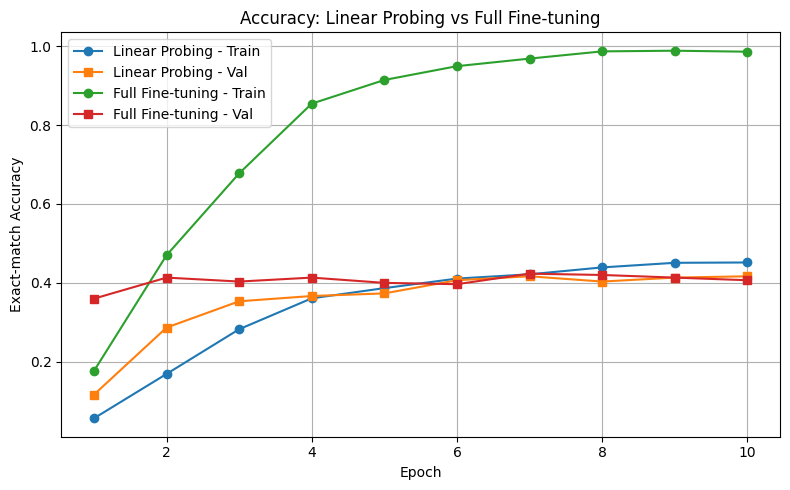

In [ ]:
# =============================================================
# 7. PLOT KURVA AKURASI
# =============================================================

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history_linear["train_acc"],
    label="Linear Probing - Train",
    marker="o"
)

plt.plot(
    epochs_range,
    history_linear["val_acc"],
    label="Linear Probing - Val",
    marker="s"
)

plt.plot(
    epochs_range,
    history_finetune["train_acc"],
    label="Full Fine-tuning - Train",
    marker="o"
)

plt.plot(
    epochs_range,
    history_finetune["val_acc"],
    label="Full Fine-tuning - Val",
    marker="s"
)

plt.title("Accuracy: Linear Probing vs Full Fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Exact-match Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("freezing_accuracy_comparison.png", dpi=150)
plt.show()